In [ ]:
#lstm
import numpy as np

In [ ]:
temperature = np.array([10,20,30,40,50,60,70,80,90,100], dtype=float)
window = 3


In [ ]:

x = []
y = []
for i in range(len(temperature) - window):
    x.append(temperature[i:i+window])
    y.append(temperature[i+window])
x = np.array(x)
y = np.array(y)

In [ ]:
x


array([[10., 20., 30.],
       [20., 30., 40.],
       [30., 40., 50.],
       [40., 50., 60.],
       [50., 60., 70.],
       [60., 70., 80.],
       [70., 80., 90.]])

In [ ]:
y

array([ 40.,  50.,  60.,  70.,  80.,  90., 100.])

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Flatten

In [ ]:
x.shape

(7, 3)

In [ ]:

x = x.reshape(x.shape[0], x.shape[1], 1)

AttributeError: 'builtin_function_or_method' object has no attribute 'reshape'

In [ ]:
import numpy as np

temperature = np.array([10,20,30,40,50,60,70,80,90,100], dtype=float)
window = 3

x = []
y = []

for i in range(len(temperature) - window):
    x.append(temperature[i:i+window])
    y.append(temperature[i+window])

x = np.array(x)
y = np.array(y)

# Check type before reshape
print("Type of x:", type(x))   # should print <class 'numpy.ndarray'>
print("x.shape before reshape:", x.shape)

# Now reshape safely
x = x.reshape(x.shape[0], x.shape[1], 1)

print("x.shape after reshape:", x.shape)


Type of x: <class 'numpy.ndarray'>
x.shape before reshape: (7, 3)
x.shape after reshape: (7, 3, 1)


In [ ]:
model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(window, 1)))
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

# === Train the model ===
model.fit(x, y, epochs=200, verbose=1)

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - loss: 5251.5249
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 5202.5229
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 5151.2905
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 5095.4800
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 5034.4468
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 4968.2563
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 4896.5078
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 4818.3740
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 4732.6616
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 4637.6929
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 4531.3140
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 4410.8882
Epoch 13/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - loss: 4273.4380
Epoch 14/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - loss: 4116.1504
Epoch 15/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - lo

In [ ]:
x_input=np.array([80,90,100])
temp_input=list(x_input)
lst_output=[]
i=0
while(i<7):
  # Take the last 'window' values
  x_input = np.array(temp_input[-window:])
  print("{} day input {}".format(i,x_input))
  x_input=x_input.reshape(1,window,1)
  yhat=model.predict(x_input,verbose=0)
  print("{} day output {}".format(i,yhat))
  temp_input.append(yhat[0][0])
  lst_output.append(yhat[0][0])

  i=i+1

0 day input [ 90 100]


ValueError: cannot reshape array of size 2 into shape (1,3,1)

In [ ]:
import numpy as np

# start with last 3 known temperatures
x_input = np.array([80, 90, 100])
temp_input = list(x_input)
lst_output = []
i = 0

while (i < 7):
    # take the last 'window' values
    x_input = np.array(temp_input[-window:])
    print(f"{i} day input: {x_input}")

    # reshape to LSTM input: (samples, timesteps, features)
    x_input = x_input.reshape(1, window, 1)

    # predict next temperature
    yhat = model.predict(x_input, verbose=0)
    print(f"{i} day output: {yhat[0][0]}")

    # append prediction
    temp_input.append(yhat[0][0])
    lst_output.append(yhat[0][0])

    i += 1

print("\nPredicted next 7 temperatures:")
print(lst_output)


0 day input: [ 80  90 100]
0 day output: 113.51356506347656
1 day input: [ 90.         100.         113.51356506]
1 day output: 126.49003601074219
2 day input: [100.         113.51356506 126.49003601]
2 day output: 140.8756103515625
3 day input: [113.513565 126.490036 140.87561 ]
3 day output: 158.47647094726562
4 day input: [126.490036 140.87561  158.47647 ]
4 day output: 176.7034454345703
5 day input: [140.87561 158.47647 176.70345]
5 day output: 197.45584106445312
6 day input: [158.47647 176.70345 197.45584]
6 day output: 221.54051208496094

Predicted next 7 temperatures:
[np.float32(113.513565), np.float32(126.490036), np.float32(140.87561), np.float32(158.47647), np.float32(176.70345), np.float32(197.45584), np.float32(221.54051)]


In [ ]:
#self
x_input = np.array([80, 90, 100])
temp_input = list(x_input)
lst_output = []

i = 0
while (i < 7):   # predict next 7 values
    x_input = np.array(temp_input[-3:])  # last 3 values
    x_input = x_input.reshape((1, 3, 1))  # reshape to [samples, timesteps, features]
    yhat = model.predict(x_input, verbose=0)
    print(f"Predicted value {i+1}: {yhat[0][0]}")

    temp_input.append(yhat[0][0])   # add prediction to input list
    lst_output.append(yhat[0][0])   # store output
    i += 1

print("\nPredicted next 7 temperatures:")
print(lst_output)

Predicted value 1: 113.51356506347656
Predicted value 2: 126.49003601074219
Predicted value 3: 140.8756103515625
Predicted value 4: 158.47647094726562
Predicted value 5: 176.7034454345703
Predicted value 6: 197.45584106445312
Predicted value 7: 221.54051208496094

Predicted next 7 temperatures:
[np.float32(113.513565), np.float32(126.490036), np.float32(140.87561), np.float32(158.47647), np.float32(176.70345), np.float32(197.45584), np.float32(221.54051)]


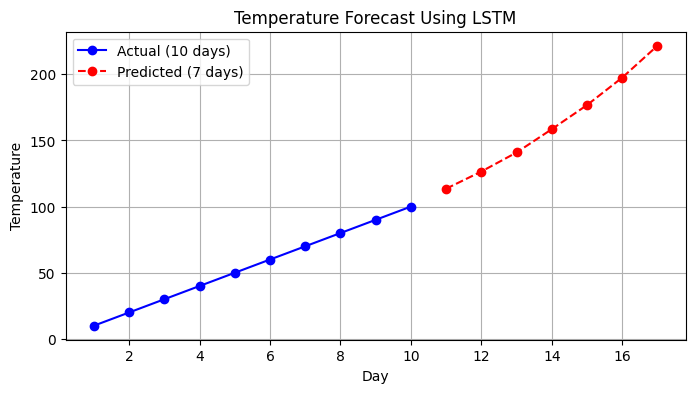

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# actual + predicted data
actual = [10,20,30,40,50,60,70,80,90,100]
predicted = lst_output  # your 7 predicted values

# combine
all_data = actual + predicted
day = np.arange(1, len(all_data) + 1)

# plot
plt.figure(figsize=(8,4))
plt.plot(day[:len(actual)], actual, 'bo-', label='Actual (10 days)')
plt.plot(day[len(actual):], predicted, 'ro--', label='Predicted (7 days)')
plt.xlabel('Day')
plt.ylabel('Temperature')
plt.title('Temperature Forecast Using LSTM')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
import matplotlib.pyplot as plt


In [ ]:
day=np.arange(1,15)
day_pred=np.arange(8,15)

In [ ]:
day

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

In [ ]:
y=np.array(temp_input)